# Импорт библиотек

In [1]:
import pandas as pd
import numpy as np
import gc
from datetime import datetime as dt
from datetime import date
from sklearn.metrics import root_mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore")

import hydroeval as he
from lumod import tools, MonteCarlo
from lumod.models import HBV
from lumod.fluxes import pet_models

# Чтение исходных данных

In [2]:
hydro_meteo_data = pd.read_excel("Velva_ERA.xlsx")

In [3]:
hydro_q_data = pd.read_excel("HydroMeteo20082020.xlsx")

In [4]:
hydro_meteo_data['qt'] = hydro_q_data["Q"]

# Подготовка данных под формат библиотеки

In [5]:
def ready_data(hydro_meteo_data):
    # выставляем дату как индекс
    hydro_meteo_data.set_index("date", inplace=True)
    # переименовываем столбцы под нужный формат
    hydro_meteo_data = hydro_meteo_data.rename(columns={"Temp": "tmean", "Prec": "prec","E_Oudin": "pet"})
    # выставлем столбцы в правильном порядке
    hydro_meteo_data = hydro_meteo_data[["prec", "tmean", "qt", "pet"]]
    # заменяем все строки на числа
    hydro_data_df = hydro_meteo_data.dropna().sort_index()
    return hydro_data_df

In [6]:
hydro_data = ready_data(hydro_meteo_data)

In [7]:
hydro_data

,prec,tmean,qt,pet
date,,,,
2008-01-01,0.734668,-6.837517,1.65,0.0
2008-01-02,0.116772,-15.883598,1.65,0.0
2008-01-03,0.301587,-13.599077,1.65,0.0
2008-01-04,0.328720,-12.357620,1.65,0.0
2008-01-05,0.274964,-11.581739,1.65,0.0
...,...,...,...,...
2020-12-27,3.813585,-8.517722,0.61,0.0
2020-12-28,0.388391,-13.732588,0.60,0.0
2020-12-29,0.132068,-21.420185,0.60,0.0


# Проверка данных на пропуски

In [8]:
print(list(hydro_data.asfreq(freq='D').index.difference(hydro_data.index)))

[]


In [9]:
hydro_data

,prec,tmean,qt,pet
date,,,,
2008-01-01,0.734668,-6.837517,1.65,0.0
2008-01-02,0.116772,-15.883598,1.65,0.0
2008-01-03,0.301587,-13.599077,1.65,0.0
2008-01-04,0.328720,-12.357620,1.65,0.0
2008-01-05,0.274964,-11.581739,1.65,0.0
...,...,...,...,...
2020-12-27,3.813585,-8.517722,0.61,0.0
2020-12-28,0.388391,-13.732588,0.60,0.0
2020-12-29,0.132068,-21.420185,0.60,0.0


# Даты начала(с разогревом) и конца калибровки

In [10]:
cal_date_start_minus_one = date(2008, 1, 1)
cal_date_end = date(2016, 12, 31)

# Калибровка

In [ ]:
# площать и широта
area, lat = 830, 58.5

In [ ]:
model_HBV = HBV(
    area = area,
    lat = lat,
)
xobs = hydro_data[["qt"]]

bounds =  { 
    "tthres": (-2, 5),
    "dd": (1.5, 4),
    "beta": (1, 6),
    "fc": (0, 1000),
    "k0": (0.01, 9),
    "k1": (0.001, 2),
    "k2": (0.0001, 0.01),
    "kp": (0, 2), # recession coefficient of percolation (1/d)
    "snow0": (-10, 100),
    "w01": (50, 500),
    "w02": (10, 100),
    "lthres": (10, 100),
    'pwp': (0.1, 1), # Soil permanente wilting point as a fraction of fc (-) [0,1]
    "s0": (0.1, 1), # Initial soil moisture storage (s/fc) [0-1]
    "cevp": (0.5, 30),# PET parameter that depends of land use (mm/day.°C)
}
score1 = {
    "var": "qt",
    "metric": "nse",
    "weight": 1
}
scores = [score1]

mc_res = MonteCarlo(
    model_HBV,
    hydro_data[cal_date_start_minus_one:cal_date_end],
    bounds,
    numsimul=200000,
    save_vars=["qt"],
    xobs=xobs,
    scores=scores,
    keep_best=1,
    start=cal_date_start_minus_one,
    end=cal_date_end
)
gc.collect()

Progress: |██████████████████████████████████████████████████| 100.0% Complete


0

In [13]:
parameters = mc_res["parameters"].to_dict(orient="index")[1]

# Сбор статистики и первоначальная визуализация калибровки

In [15]:
def calibration(df, start_c, end_c, area, lat, parameters_calibration):
    model_HBV = HBV(area=area, lat=lat, params=parameters_calibration)

    sim_cal = model_HBV.run(df, start=start_c, end=end_c)
    metrics_cal = tools.metrics.summary(df["qt"], sim_cal["qt"])
    print("Calibration period")
    
    tools.plots.model_evaluation(df["prec"], df["qt"], sim_cal["qt"],
                                 start=start_c, end=end_c)

    return metrics_cal, sim_cal

Calibration period


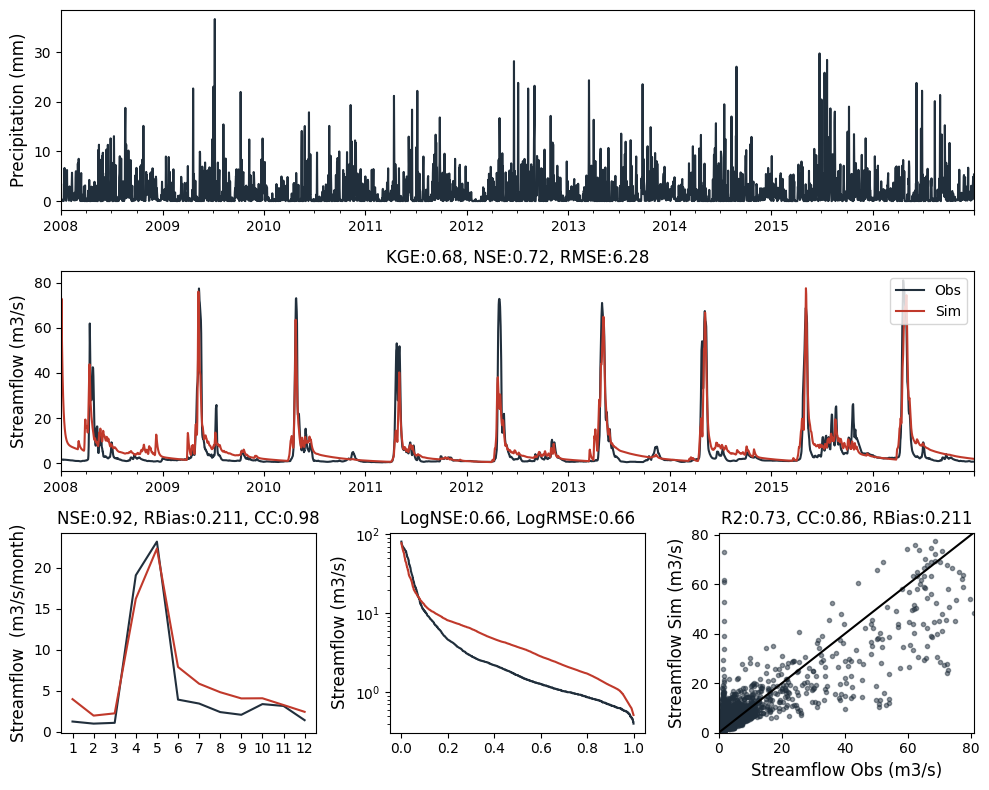

In [16]:
metrics, cal= calibration(hydro_data, cal_date_start_minus_one, cal_date_end, area, lat, parameters)

# Преобразование и вычищение полученных данных

In [17]:
df_hydro_calibration = pd.DataFrame()
df_hydro_calibration["Observed values"] =  hydro_data.loc[cal_date_start_minus_one:cal_date_end].qt.apply(lambda x: float(x))
df_hydro_calibration["Simulated values"] =  cal.loc[cal_date_start_minus_one:cal_date_end].qt
df_hydro_calibration = df_hydro_calibration[cal_date_start_minus_one.replace(year=cal_date_start_minus_one.year + 1):]
df_hydro_calibration = df_hydro_calibration.dropna()
df_hydro_calibration = df_hydro_calibration[df_hydro_calibration["Simulated values"] != np.inf]
df_hydro_calibration = df_hydro_calibration[df_hydro_calibration["Simulated values"] > -np.inf]

# Сохранение в эксель

In [18]:
df_hydro_calibration.to_excel("NSE КАЛИБРОВКА MC ДЛЯ СТАТЬИ ВЕЛЬВА РЕАНАЛИЗ 2009 по 2016.xlsx")

# Вывод метрик

In [20]:

metrics_calibration = {
    "NSE" : round(float((he.evaluator(he.nse, df_hydro_calibration["Simulated values"].values, df_hydro_calibration["Observed values"].values))[0]), 2), 
    "KGE": round(float((he.evaluator(he.kge, df_hydro_calibration["Simulated values"].values, df_hydro_calibration["Observed values"].values))[0]), 2),
    "RMSE": round(root_mean_squared_error(df_hydro_calibration["Observed values"].values, df_hydro_calibration["Simulated values"].values), 2),
    "MAE": round(mean_absolute_error(df_hydro_calibration["Observed values"].values, df_hydro_calibration["Simulated values"].values), 2),
}
metrics_calibration = pd.DataFrame.from_dict([metrics_calibration])
metrics_calibration

,NSE,KGE,RMSE,MAE
0,0.8,0.74,5.54,2.8


# Визуализация по каждому году

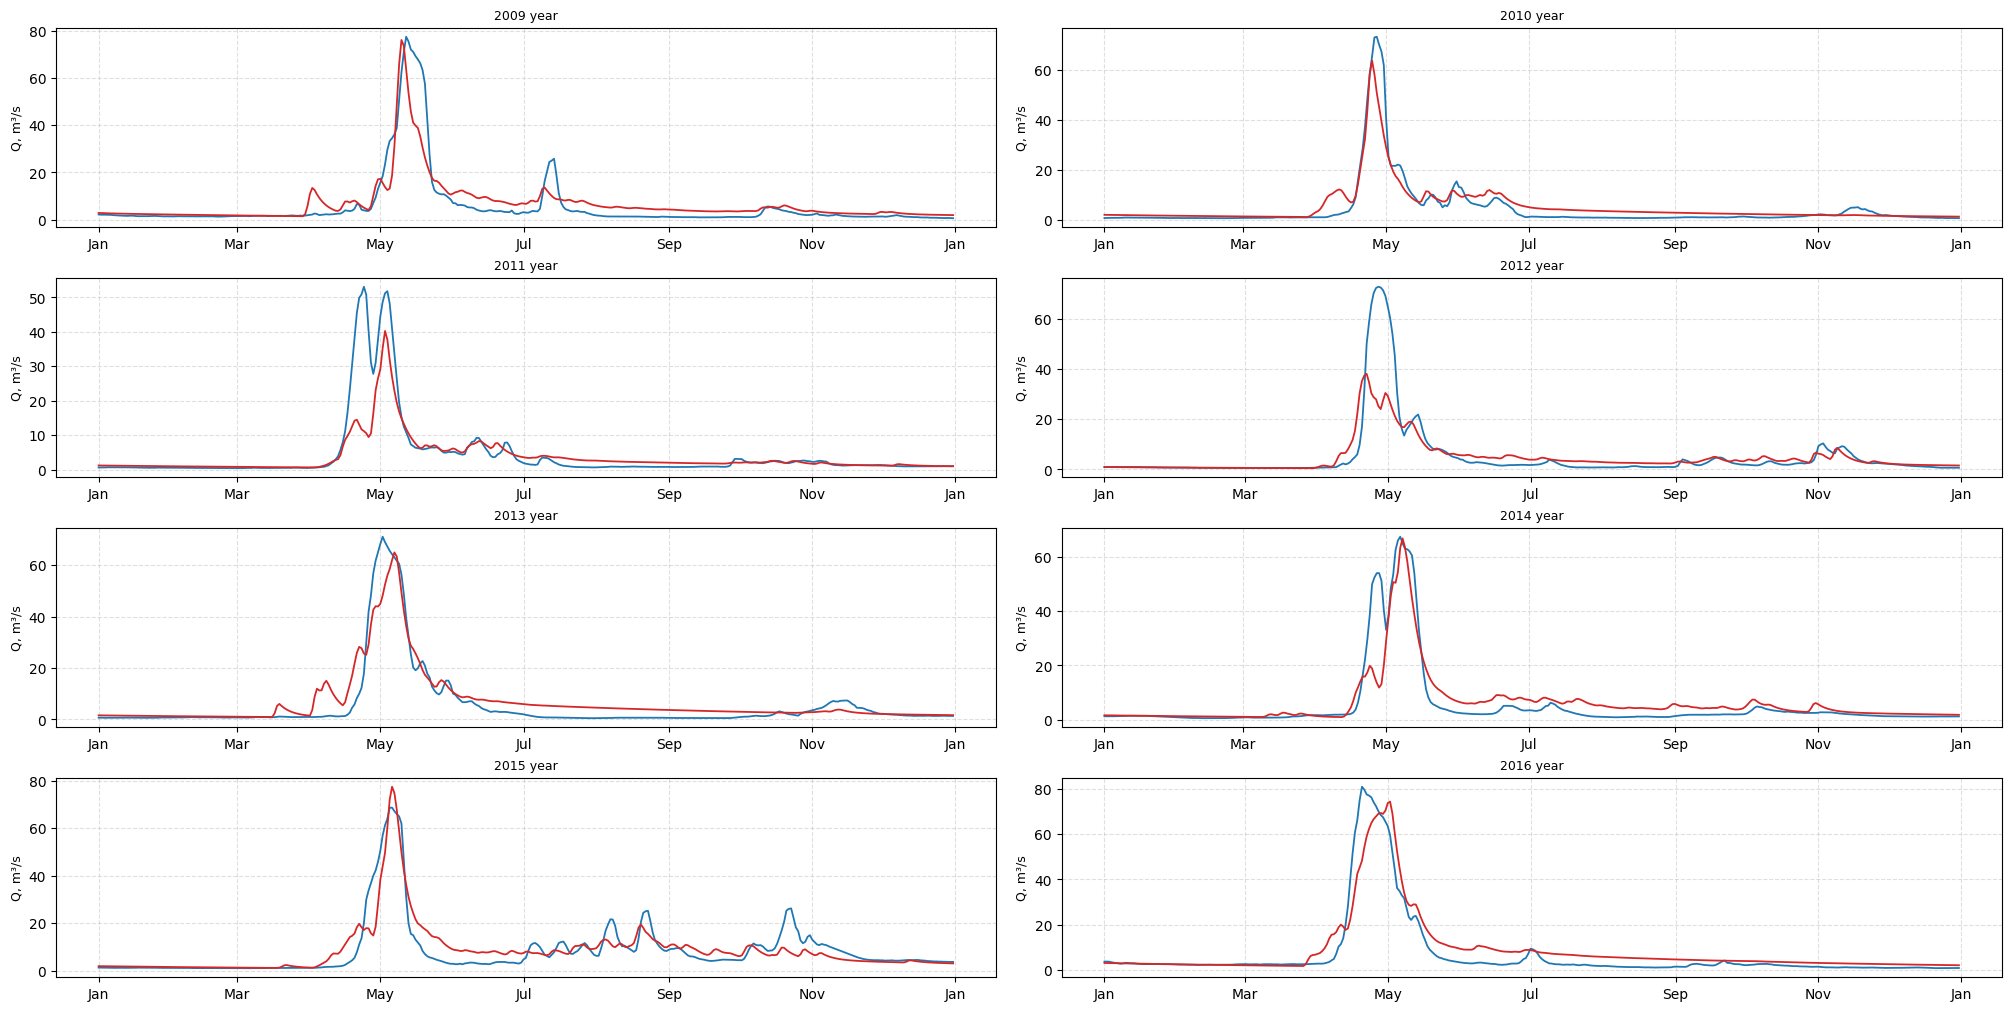

In [21]:
numeric_cols = ['Observed values', 'Simulated values']
years = sorted(df_hydro_calibration.index.year.unique())

# Оптимальное количество колонок
ncols = 2
nrows = (len(years) + ncols - 1) // ncols

fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols, 
    figsize=(20, nrows*2.5), 
    constrained_layout=True
)

# fig.suptitle('Калибровка ЭКОМАГ', fontsize=16, y=1.02)
date_format = mdates.DateFormatter("%b")

# Заглушки для легенды
lines = []
for col in numeric_cols:
    line, = axes.flat[0].plot([], [], label=col)
    lines.append(line)

# Отрисовка графиков
for i, year in enumerate(years):
    ax = axes.flat[i]
    year_data = df_hydro_calibration[df_hydro_calibration.index.year == year]

    ax.plot(year_data['Observed values'], color="#1f77b4", linewidth=1.3)
    ax.plot(year_data['Simulated values'], color="#d62728", linewidth=1.3)
    ax.set_ylabel("Q, m³/s", fontsize=9)
    ax.set_title(f'{year} year', fontsize=9)
    ax.xaxis.set_major_formatter(date_format)
    ax.grid(True, linestyle='--', alpha=0.4)

# Убираем пустые оси
for j in range(i+1, nrows*ncols):
    fig.delaxes(axes.flat[j])

# Легенду переносим вниз
# fig.legend(
#     handles=lines,
#     labels=numeric_cols,
#     loc='upper left',
#     ncol=2,
#     frameon=False,
#     fontsize=12
# )
# Добавляем отступ снизу под легенду
plt.subplots_adjust(bottom=0.10)

# plt.savefig("annual_comparison.pdf", dpi=300, bbox_inches="tight")
plt.show()

# Валидационный расчет

In [22]:
def validation(df, start_c, end_c, area, lat, parameters_calibration):
    model_HBV = HBV(area=area, lat=lat, params=parameters_calibration)

    sim_cal = model_HBV.run(df, start=start_c, end=end_c)
    metrics_cal = tools.metrics.summary(df["qt"], sim_cal["qt"])
    print("validation period")
    
    tools.plots.model_evaluation(df["prec"], df["qt"], sim_cal["qt"],
                                 start=start_c, end=end_c)

    return metrics_cal, sim_cal

# Даты начала(с разогревом) и конца валидации

In [23]:
val_date_start_minus_one = date(2016, 1, 1)
val_date_end = date(2021, 12, 31)

validation period


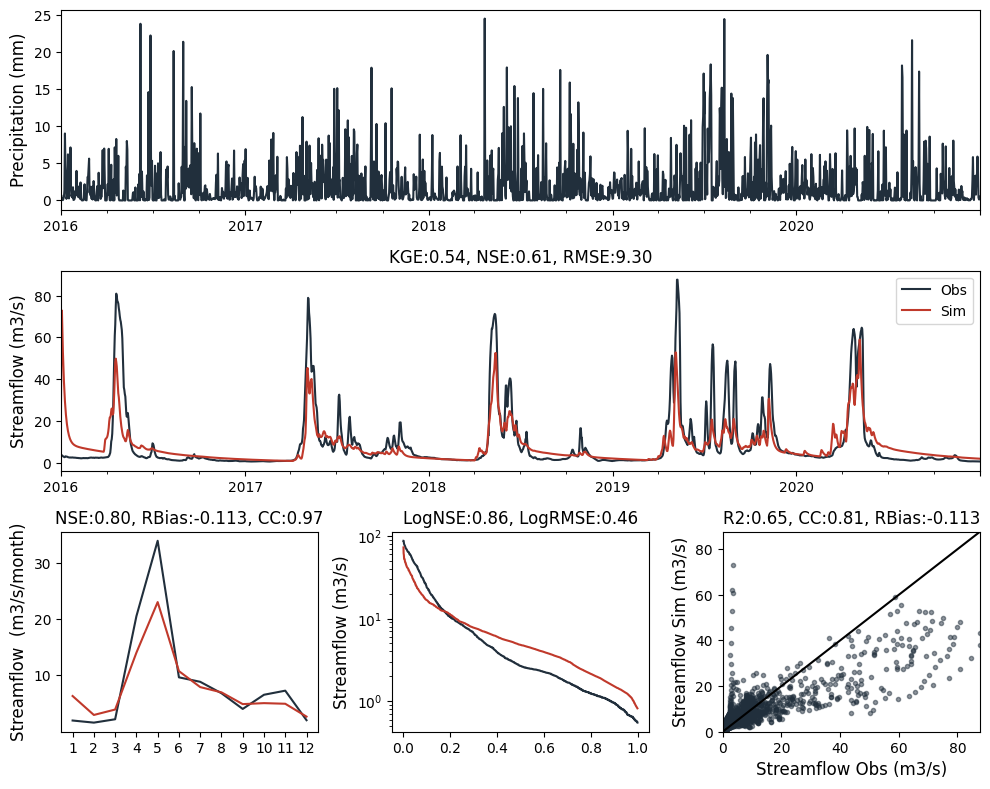

In [24]:
metrics_val, val= validation(hydro_data, val_date_start_minus_one, val_date_end, area, lat, parameters)

In [25]:
df_hydro_validation = pd.DataFrame()
df_hydro_validation["Observed values"] =  hydro_data.loc[val_date_start_minus_one:val_date_end].qt
df_hydro_validation["Simulated values"] =  val.loc[val_date_start_minus_one:val_date_end].qt
df_hydro_validation = df_hydro_validation[val_date_start_minus_one.replace(year=val_date_start_minus_one.year + 1):]
df_hydro_validation = df_hydro_validation.dropna()
df_hydro_validation = df_hydro_validation[df_hydro_validation["Simulated values"] != np.inf]
df_hydro_validation = df_hydro_validation[df_hydro_validation["Simulated values"] > -np.inf]

# Экспорт данных по валидации в эксель

In [26]:
df_hydro_validation.to_excel("NSE ВАЛИДАЦИЯ MC ДЛЯ СТАТЬИ ВЕЛЬВА РЕАНАЛИЗ 2017 по 2021.xlsx")

# Вывод валидационных метрик

In [27]:
metrics_validation = {
    "NSE" : round(float((he.evaluator(he.nse, df_hydro_validation["Simulated values"].values, df_hydro_validation["Observed values"].values))[0]), 2), 
    "KGE": round(float((he.evaluator(he.kge, df_hydro_validation["Simulated values"].values, df_hydro_validation["Observed values"].values))[0]), 2),
   "RMSE": round(root_mean_squared_error(df_hydro_validation["Observed values"].values, df_hydro_validation["Simulated values"].values), 2),
    "MAE": round(mean_absolute_error(df_hydro_validation["Observed values"].values, df_hydro_validation["Simulated values"].values), 2),
}
metrics_validation = pd.DataFrame.from_dict([metrics_validation])
metrics_validation

,NSE,KGE,RMSE,MAE
0,0.68,0.54,8.29,4.19


# Визуализация валидационного периода за каждый год

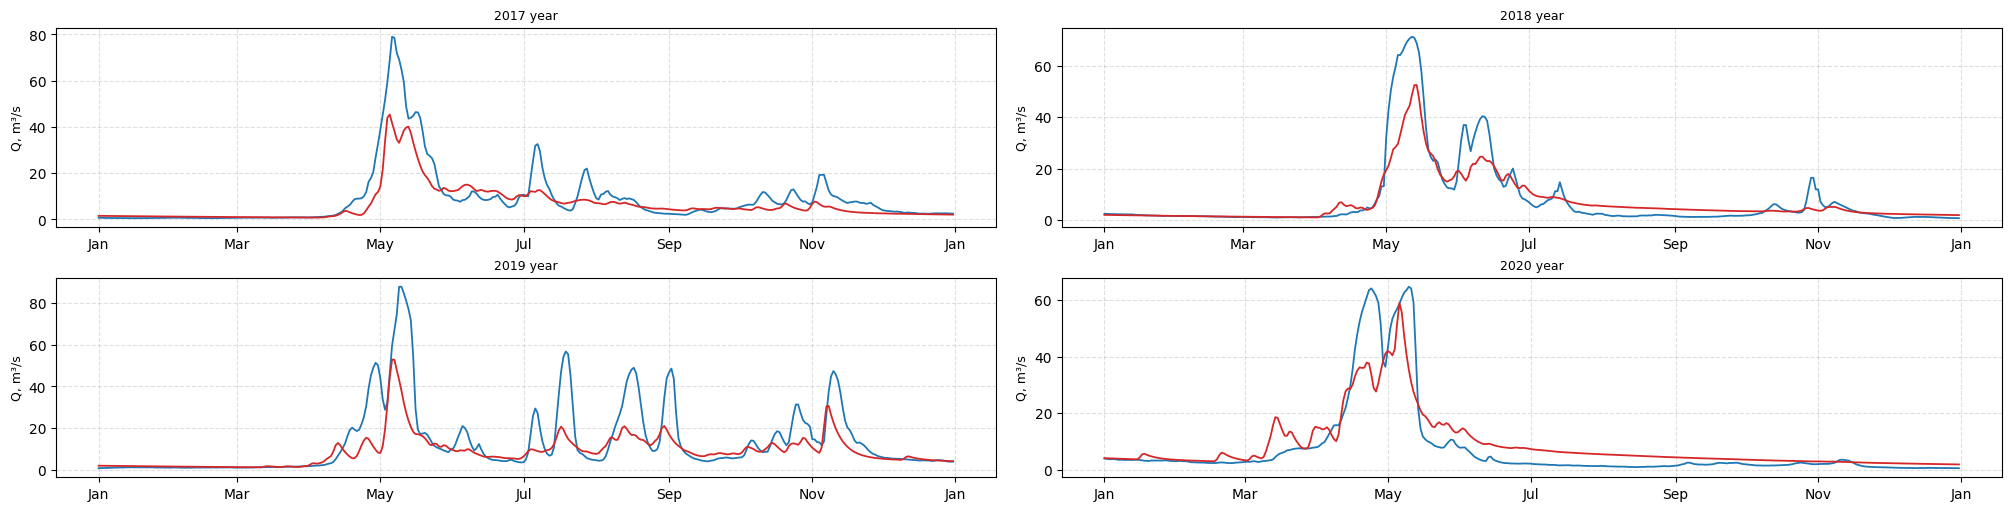

In [28]:
numeric_cols = ['Observed values', 'Simulated values']
years = sorted(df_hydro_validation.index.year.unique())

# Оптимальное количество колонок
ncols = 2
nrows = (len(years) + ncols - 1) // ncols

fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols, 
    figsize=(20, nrows*2.5), 
    constrained_layout=True
)

# fig.suptitle('Калибровка ЭКОМАГ', fontsize=16, y=1.02)
date_format = mdates.DateFormatter("%b")

# Заглушки для легенды
lines = []
for col in numeric_cols:
    line, = axes.flat[0].plot([], [], label=col)
    lines.append(line)

# Отрисовка графиков
for i, year in enumerate(years):
    ax = axes.flat[i]
    year_data = df_hydro_validation[df_hydro_validation.index.year == year]

    ax.plot(year_data['Observed values'], color="#1f77b4", linewidth=1.3)
    ax.plot(year_data['Simulated values'], color="#d62728", linewidth=1.3)
    ax.set_ylabel("Q, m³/s", fontsize=9)
    ax.set_title(f'{year} year', fontsize=9)
    ax.xaxis.set_major_formatter(date_format)
    ax.grid(True, linestyle='--', alpha=0.4)

# Убираем пустые оси
for j in range(i+1, nrows*ncols):
    fig.delaxes(axes.flat[j])

# Легенду переносим вниз
# fig.legend(
#     handles=lines,
#     labels=numeric_cols,
#     loc='upper left',
#     ncol=2,
#     frameon=False,
#     fontsize=12
# )
# Добавляем отступ снизу под легенду
plt.subplots_adjust(bottom=0.10)

# plt.savefig("annual_comparison.pdf", dpi=300, bbox_inches="tight")
plt.show()